In [37]:
import pandas as pd
import os
import json

def parse_json_stream(file_path):
    """
    Parses a file containing a stream of concatenated JSON objects.
    """
    with open(file_path, 'r') as f:
        content = f.read()
    
    decoder = json.JSONDecoder()
    objects = []
    pos = 0
    # Skip leading whitespace
    while pos < len(content) and content[pos].isspace():
        pos += 1
    
    while pos < len(content):
        try:
            obj, pos = decoder.raw_decode(content, pos)
            objects.append(obj)
            # Skip whitespace between objects
            while pos < len(content) and content[pos].isspace():
                pos += 1
        except json.JSONDecodeError:
            # Handle cases where decoding might fail, e.g., trailing characters
            break
            
    return objects

# Directory containing the JSON files
data_dir = 'infer_metrics'
all_metrics = []

# Check if the directory exists
if os.path.isdir(data_dir):
    # Iterate over each file in the directory
    for filename in os.listdir(data_dir):
        if filename.endswith('.json'):
            file_path = os.path.join(data_dir, filename)
            # Parse the stream of JSON objects from the file
            metrics_from_file = parse_json_stream(file_path)
            all_metrics.extend(metrics_from_file)

# Create a pandas DataFrame from the list of dictionaries
if all_metrics:
    df = pd.DataFrame(all_metrics)
    # Sort by experiment number for consistent ordering
    if 'experiment_num' in df.columns:
        df = df.sort_values(by='experiment_num').reset_index(drop=True)
    print(df.head())
else:
    print(f"No JSON files found or parsed in the '{data_dir}' directory.")
    # Create an empty dataframe to avoid errors in subsequent cells
    df = pd.DataFrame()

        model precision  pretrained device  batch_size  num_batches  \
0  bert-large      bf16        True   7900        1024          100   
1  bert-large      bf16        True   L40S          96          100   
2    resnet50      fp16        True   4090          64          100   
3  bert-large      bf16        True   L40S          96          100   
4    resnet50      fp32        True   7900          12          100   

   warmup_batches  total_samples  total_inference_time_sec  \
0               5         102400                165.554519   
1               5           9600                  6.357300   
2               5           6400                  1.313303   
3               5           9600                  6.459202   
4               5           1200                  0.771669   

   throughput_samples_per_sec  ...  p90_latency_ms  p95_latency_ms  \
0                  618.527363  ...     1657.343650     1657.601166   
1                 1510.075135  ...       63.725519       63.

In [38]:
df

,model,precision,pretrained,device,batch_size,num_batches,warmup_batches,total_samples,total_inference_time_sec,throughput_samples_per_sec,...,p90_latency_ms,p95_latency_ms,p99_latency_ms,peak_memory_mb,experiment_num,gpu_peak_memory_logger_mb,gpu_avg_util_percent,gpu_avg_power_watts,avg_utilization_percent,avg_power_watts
0,bert-large,bf16,True,7900,1024,100,5,102400,165.554519,618.527363,...,1657.343650,1657.601166,1659.690533,5698.180176,1,NaN,NaN,NaN,NaN,NaN
1,bert-large,bf16,True,L40S,96,100,5,9600,6.357300,1510.075135,...,63.725519,63.800490,63.917184,2224.036133,1,NaN,NaN,NaN,NaN,NaN
2,resnet50,fp16,True,4090,64,100,5,6400,1.313303,4873.208139,...,13.567352,13.601565,13.613913,516.368164,1,1645.187500,54.750,141.457500,NaN,NaN
3,bert-large,bf16,True,L40S,96,100,5,9600,6.459202,1486.251641,...,64.852905,64.939141,65.103581,2224.036133,1,3293.750000,93.500,293.606286,NaN,NaN
4,resnet50,fp32,True,7900,12,100,5,1200,0.771669,1555.071071,...,7.825637,7.831967,7.854350,224.102051,1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4461,gpt2,fp32,True,L40S,16,100,5,1600,1.197739,1335.850691,...,11.955595,12.202621,15.529089,1574.890625,100,2757.750000,55.000,153.945667,NaN,NaN
4462,resnet50,bf16,True,7900,32,100,5,3200,2.068038,1547.360180,...,20.816994,20.845306,20.875835,277.840332,100,728.140625,72.600,202.000000,NaN,NaN
4463,bert-large,fp16,True,4090,64,100,5,6400,4.489081,1425.681438,...,44.880319,44.898391,44.913611,2103.958008,100,3041.187500,92.600,343.462900,NaN,NaN
4464,bert-large,fp32,True,L40S,32,100,5,3200,3.662842,873.638662,...,36.815429,36.875975,36.985264,1463.426758,100,NaN,NaN,NaN,NaN,NaN


Device Performance and Efficiency Summary:
  device  mean_throughput  mean_peak_memory_mb  efficiency_throughput_per_mb
0   4090      2259.036099          1458.041908                      1.549363
2   L40S      2165.311281          1330.251937                      1.627745
1   7900      1038.347029          2035.857947                      0.510029


/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_88186/1076338899.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_summary, x='device', y='mean_throughput', ax=axes[0], palette='viridis')
/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_88186/1076338899.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_summary, x='device', y='mean_peak_memory_mb', ax=axes[1], palette='plasma')
/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_88186/1076338899.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

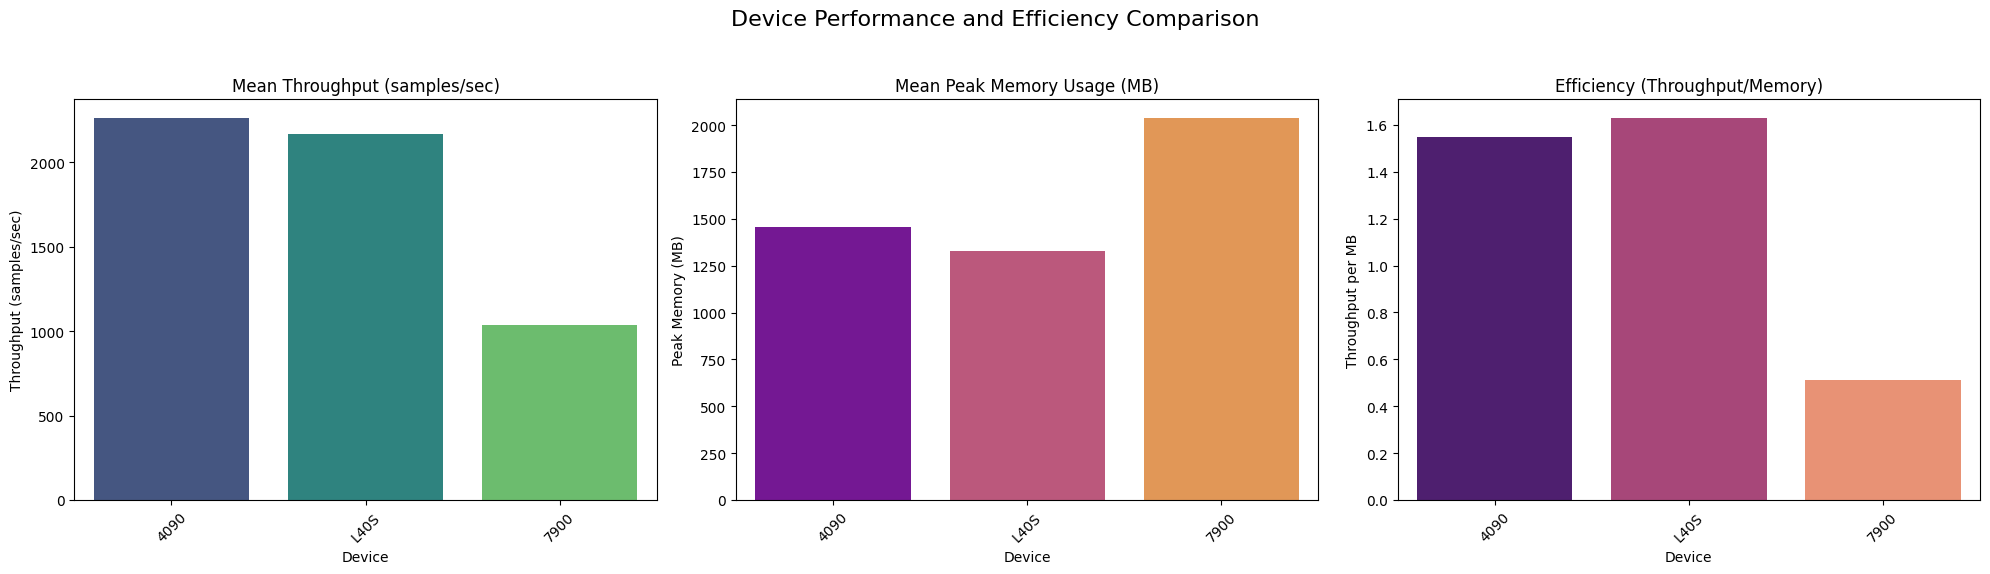

In [39]:
import seaborn as sns

import matplotlib.pyplot as plt

if not df.empty:
    # Group by device and calculate the mean for performance and memory metrics
    device_summary = df.groupby('device').agg(
        mean_throughput=('throughput_samples_per_sec', 'mean'),
        mean_peak_memory_mb=('peak_memory_mb', 'mean')
    ).reset_index()

    # Calculate an efficiency score: throughput per megabyte of peak memory
    device_summary['efficiency_throughput_per_mb'] = device_summary['mean_throughput'] / device_summary['mean_peak_memory_mb']

    # Sort by mean throughput for clearer visualization
    device_summary = device_summary.sort_values(by='mean_throughput', ascending=False)

    print("Device Performance and Efficiency Summary:")
    print(device_summary)

    # Create subplots for visualization
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Device Performance and Efficiency Comparison', fontsize=16)

    # Plot Mean Throughput
    sns.barplot(data=device_summary, x='device', y='mean_throughput', ax=axes[0], palette='viridis')
    axes[0].set_title('Mean Throughput (samples/sec)')
    axes[0].set_ylabel('Throughput (samples/sec)')
    axes[0].set_xlabel('Device')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot Mean Peak Memory
    sns.barplot(data=device_summary, x='device', y='mean_peak_memory_mb', ax=axes[1], palette='plasma')
    axes[1].set_title('Mean Peak Memory Usage (MB)')
    axes[1].set_ylabel('Peak Memory (MB)')
    axes[1].set_xlabel('Device')
    axes[1].tick_params(axis='x', rotation=45)

    # Plot Efficiency
    sns.barplot(data=device_summary, x='device', y='efficiency_throughput_per_mb', ax=axes[2], palette='magma')
    axes[2].set_title('Efficiency (Throughput/Memory)')
    axes[2].set_ylabel('Throughput per MB')
    axes[2].set_xlabel('Device')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("DataFrame is empty. No comparison can be made.")

---

=== GPU-SPECIFIC PERFORMANCE ANALYSIS: FP32 vs FP16 vs BF16 ===

GPU: RX 7900 XTX

--- BERT-LARGE MODEL ---
Precision  Throughput   Power (W)  Efficiency   Max Batch  Avg Memory  
(type)     (samp/sec)   (watts)    (samp/W)     Size       (MB)        
------------------------------------------------------------------------------
fp32       46.7         252.2      0.185        4          1371.3      
fp16       613.0        273.3      2.243        1024       5698.2      
bf16       618.4        265.4      2.330        1024       5698.2      

Performance Gains over FP32 baseline:
Precision  Throughput      Power           Efficiency     
(type)     Gain (%)        Change (%)      Gain (%)       
------------------------------------------------------------
fp16       1213.8          8.4             1112.2         
bf16       1225.3          5.3             1159.1         


--- RESNET50 MODEL ---
Precision  Throughput   Power (W)  Efficiency   Max Batch  Avg Memory  
(type)     (samp/sec

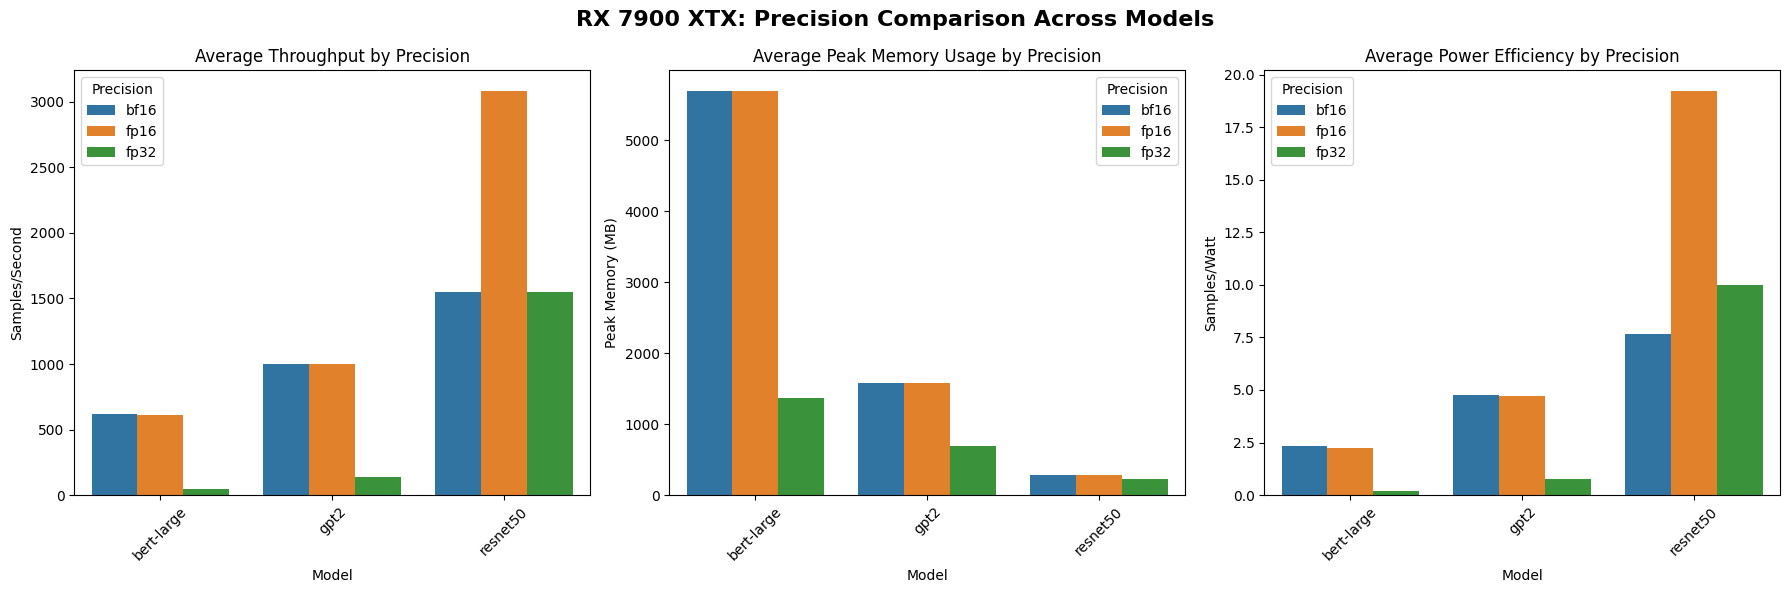

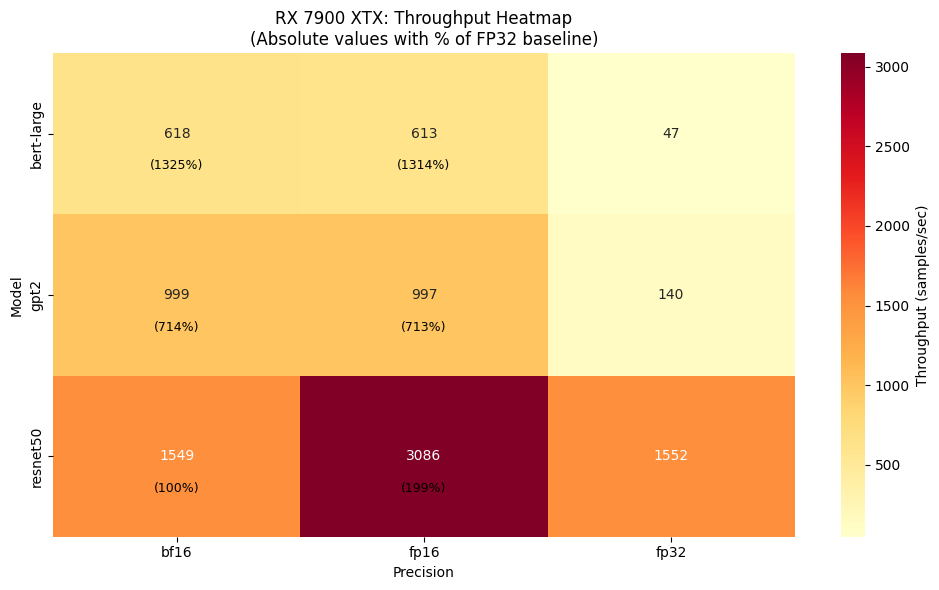

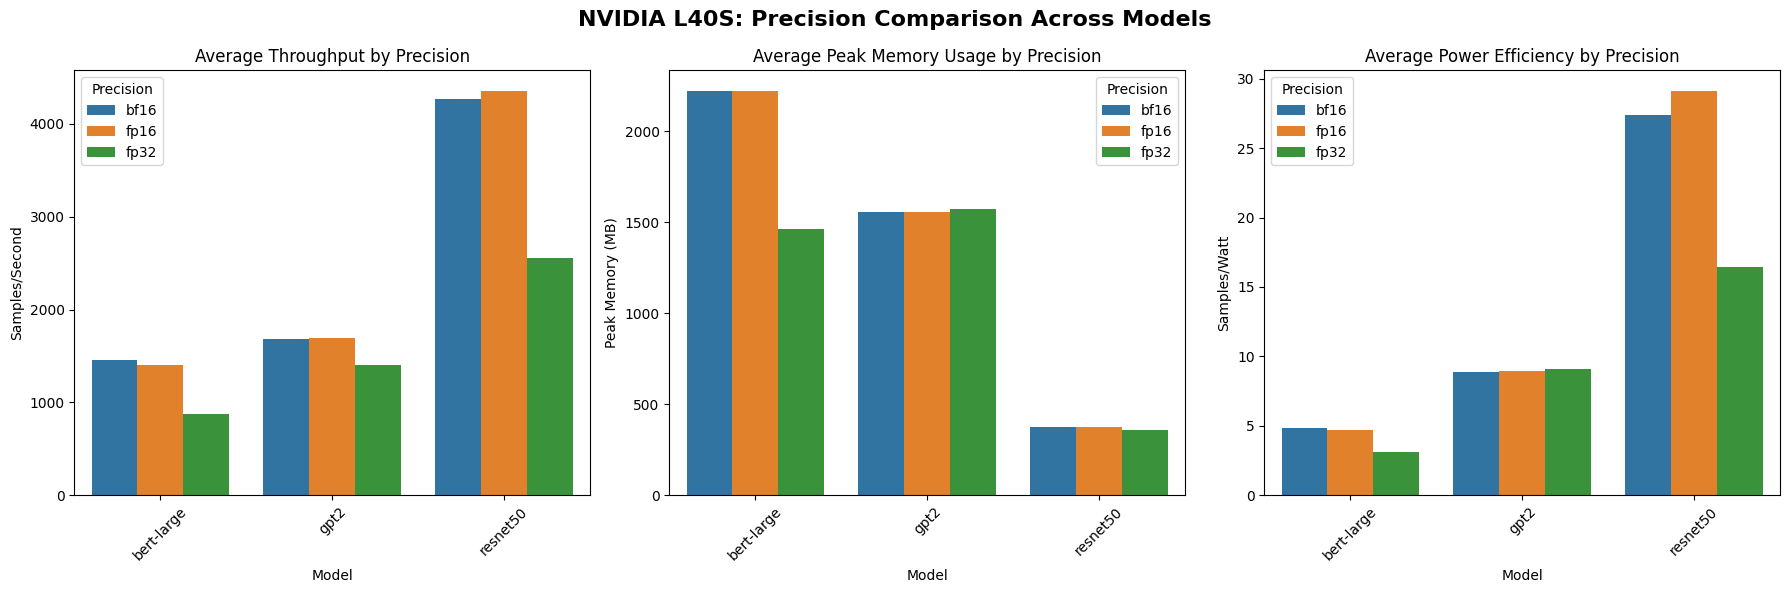

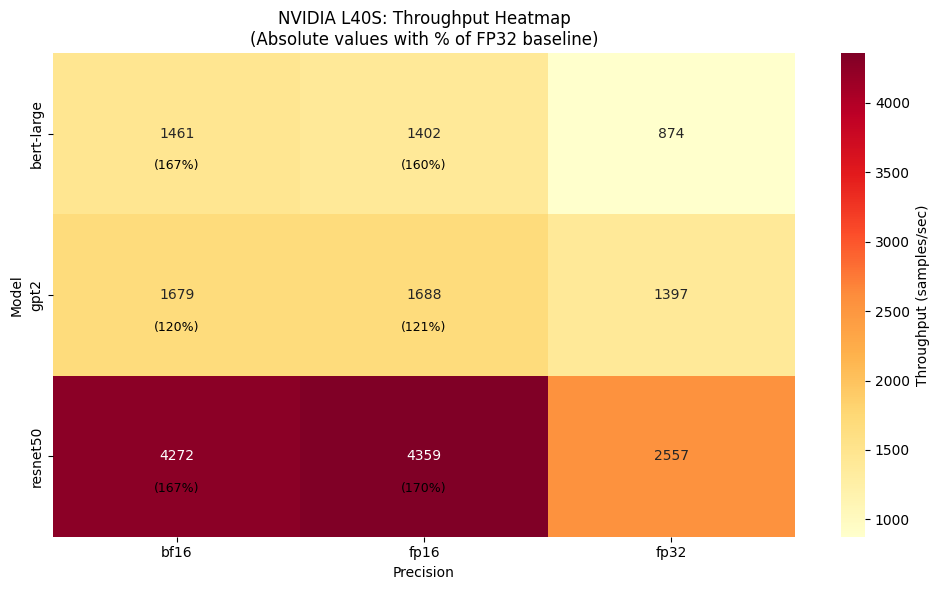

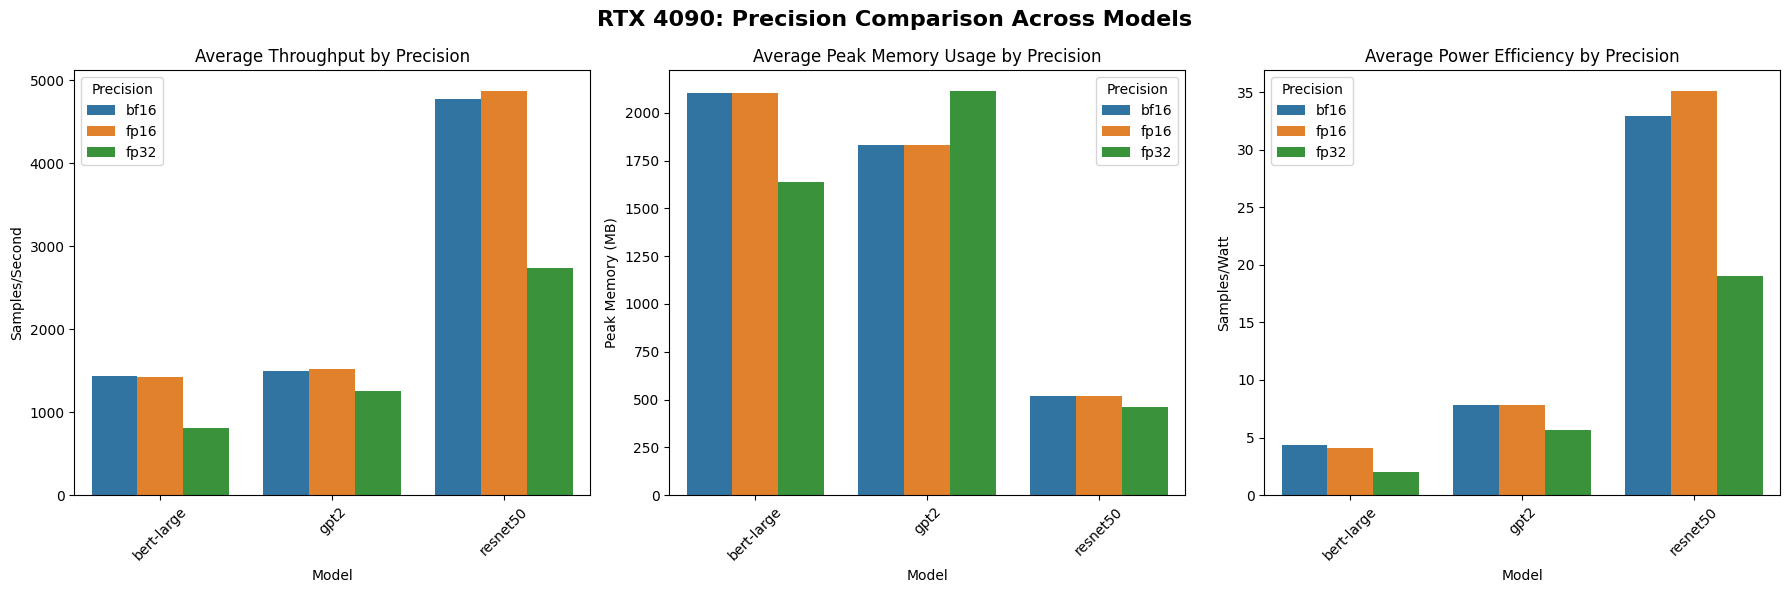

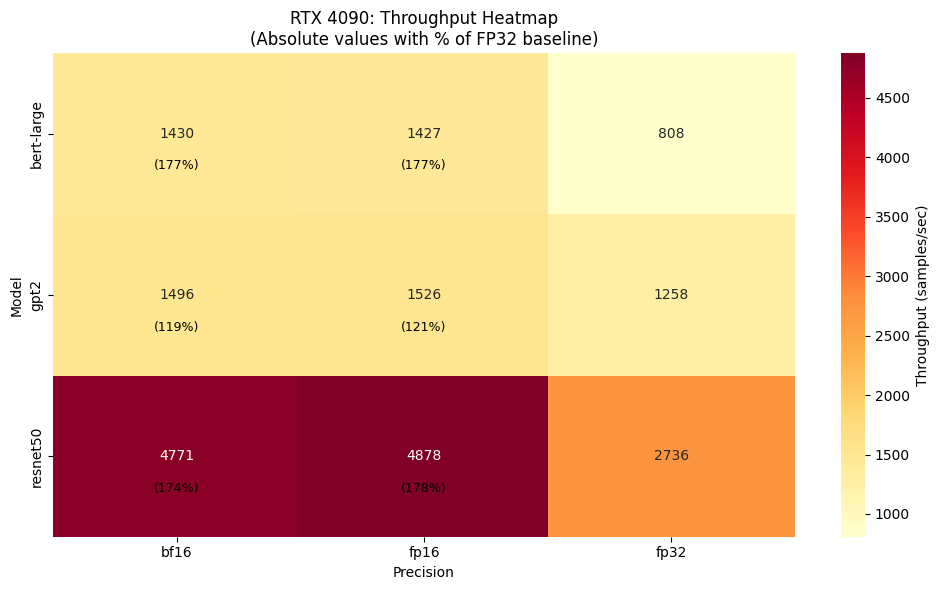

In [40]:
import seaborn as sns
import pandas as pd

# Create performance comparison analysis for each GPU: FP32 vs FP16 vs BF16
print("=== GPU-SPECIFIC PERFORMANCE ANALYSIS: FP32 vs FP16 vs BF16 ===\n")

# Map device names to more readable GPU names
device_to_gpu = {'4090': 'RTX 4090', '7900': 'RX 7900 XTX', 'L40S': 'NVIDIA L40S'}

for device in df['device'].unique():
    gpu_name = device_to_gpu.get(device, device)
    print(f"{'='*60}")
    print(f"GPU: {gpu_name}")
    print(f"{'='*60}")
    
    gpu_data = df_analysis[df_analysis['device'] == device]
    
    for model in gpu_data['model'].unique():
        print(f"\n--- {model.upper()} MODEL ---")
        model_gpu_data = gpu_data[gpu_data['model'] == model]
        
        # Calculate metrics for each precision
        precision_metrics = {}
        for precision in ['fp32', 'fp16', 'bf16']:
            precision_data = model_gpu_data[model_gpu_data['precision'] == precision]
            if not precision_data.empty:
                # Use available power data (prioritize gpu_avg_power_watts, fallback to avg_power_watts)
                power_col = 'gpu_avg_power_watts' if precision_data['gpu_avg_power_watts'].notna().any() else 'avg_power_watts'
                avg_power = precision_data[power_col].mean() if precision_data[power_col].notna().any() else None
                
                precision_metrics[precision] = {
                    'avg_throughput': precision_data['throughput_samples_per_sec'].mean(),
                    'avg_power': avg_power,
                    'avg_efficiency': precision_data['throughput_samples_per_sec'].mean() / avg_power if avg_power else None,
                    'max_batch_size': precision_data['batch_size'].max(),
                    'avg_memory': precision_data['peak_memory_mb'].mean()
                }
        
        # Display metrics table
        if precision_metrics:
            print(f"{'Precision':<10} {'Throughput':<12} {'Power (W)':<10} {'Efficiency':<12} {'Max Batch':<10} {'Avg Memory':<12}")
            print(f"{'(type)':<10} {'(samp/sec)':<12} {'(watts)':<10} {'(samp/W)':<12} {'Size':<10} {'(MB)':<12}")
            print("-" * 78)
            
            for precision, metrics in precision_metrics.items():
                power_str = f"{metrics['avg_power']:.1f}" if metrics['avg_power'] else "N/A"
                efficiency_str = f"{metrics['avg_efficiency']:.3f}" if metrics['avg_efficiency'] else "N/A"
                print(f"{precision:<10} {metrics['avg_throughput']:<12.1f} {power_str:<10} "
                      f"{efficiency_str:<12} {metrics['max_batch_size']:<10} {metrics['avg_memory']:<12.1f}")
        
        # Calculate performance improvements over FP32 baseline
        if 'fp32' in precision_metrics:
            fp32_baseline = precision_metrics['fp32']
            print(f"\nPerformance Gains over FP32 baseline:")
            print(f"{'Precision':<10} {'Throughput':<15} {'Power':<15} {'Efficiency':<15}")
            print(f"{'(type)':<10} {'Gain (%)':<15} {'Change (%)':<15} {'Gain (%)':<15}")
            print("-" * 60)
            
            for precision in ['fp16', 'bf16']:
                if precision in precision_metrics:
                    curr_metrics = precision_metrics[precision]
                    
                    throughput_gain = ((curr_metrics['avg_throughput'] / fp32_baseline['avg_throughput']) - 1) * 100
                    
                    if curr_metrics['avg_power'] and fp32_baseline['avg_power']:
                        power_change = ((curr_metrics['avg_power'] / fp32_baseline['avg_power']) - 1) * 100
                        efficiency_gain = ((curr_metrics['avg_efficiency'] / fp32_baseline['avg_efficiency']) - 1) * 100
                        print(f"{precision:<10} {throughput_gain:<15.1f} {power_change:<15.1f} {efficiency_gain:<15.1f}")
                    else:
                        print(f"{precision:<10} {throughput_gain:<15.1f} {'N/A':<15} {'N/A':<15}")
        
        print()

# Create visualization comparing precisions for each GPU
import matplotlib.pyplot as plt

for device in df['device'].unique():
    gpu_name = device_to_gpu.get(device, device)
    gpu_data = df_analysis[df_analysis['device'] == device]
    
    # Prepare data for plotting
    gpu_summary = gpu_data.groupby(['model', 'precision']).agg(
        avg_throughput_samples_per_sec=('throughput_samples_per_sec', 'mean'),
        avg_peak_memory_mb=('peak_memory_mb', 'mean'),
        avg_gpu_power_watts=('gpu_avg_power_watts', lambda x: x.dropna().mean() if x.notna().any() else None)
    ).reset_index()
    
    # Calculate efficiency where power data is available
    gpu_summary['avg_efficiency'] = gpu_summary.apply(
        lambda row: row['avg_throughput_samples_per_sec'] / row['avg_gpu_power_watts'] 
        if pd.notna(row['avg_gpu_power_watts']) else None, axis=1
    )
    
    if not gpu_summary.empty:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f'{gpu_name}: Precision Comparison Across Models', fontsize=16, fontweight='bold')
        
        # Throughput comparison
        sns.barplot(data=gpu_summary, x='model', y='avg_throughput_samples_per_sec', hue='precision', ax=axes[0])
        axes[0].set_title('Average Throughput by Precision')
        axes[0].set_ylabel('Samples/Second')
        axes[0].set_xlabel('Model')
        axes[0].legend(title='Precision')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Memory usage comparison
        sns.barplot(data=gpu_summary, x='model', y='avg_peak_memory_mb', hue='precision', ax=axes[1])
        axes[1].set_title('Average Peak Memory Usage by Precision')
        axes[1].set_ylabel('Peak Memory (MB)')
        axes[1].set_xlabel('Model')
        axes[1].legend(title='Precision')
        axes[1].tick_params(axis='x', rotation=45)
        
        # Efficiency comparison (only if power data is available)
        efficiency_data = gpu_summary.dropna(subset=['avg_efficiency'])
        if not efficiency_data.empty:
            sns.barplot(data=efficiency_data, x='model', y='avg_efficiency', hue='precision', ax=axes[2])
            axes[2].set_title('Average Power Efficiency by Precision')
            axes[2].set_ylabel('Samples/Watt')
            axes[2].set_xlabel('Model')
            axes[2].legend(title='Precision')
            axes[2].tick_params(axis='x', rotation=45)
        else:
            axes[2].text(0.5, 0.5, 'No power data available', ha='center', va='center', transform=axes[2].transAxes)
            axes[2].set_title('Power Efficiency (No Data Available)')
        
        plt.tight_layout()
        plt.show()
        
        # Create heatmap for throughput comparison
        heatmap_data = gpu_summary.pivot(index='model', columns='precision', values='avg_throughput_samples_per_sec')
        
        # Calculate percentage of FP32 throughput for each precision
        fp32_baseline = heatmap_data['fp32'] if 'fp32' in heatmap_data.columns else None
        heatmap_percent = heatmap_data.copy()
        
        if fp32_baseline is not None:
            for col in heatmap_percent.columns:
                if col != 'fp32':
                    heatmap_percent[col] = (heatmap_percent[col] / fp32_baseline) * 100
                heatmap_percent['fp32'] = 100  # FP32 is 100% of itself
        
        # Create separate figure for heatmap
        fig_heatmap, ax_heatmap = plt.subplots(1, 1, figsize=(10, 6))
        
        # Create heatmap with annotations showing both absolute values and percentages
        sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', 
               ax=ax_heatmap, cbar_kws={'label': 'Throughput (samples/sec)'})
        
        # Add percentage annotations if we have FP32 baseline
        if fp32_baseline is not None:
            for i, model in enumerate(heatmap_data.index):
                for j, precision in enumerate(heatmap_data.columns):
                    if precision != 'fp32' and not pd.isna(heatmap_percent.iloc[i, j]):
                        percent_val = heatmap_percent.iloc[i, j]
                        ax_heatmap.text(j + 0.5, i + 0.7, f'({percent_val:.0f}%)', 
                                ha='center', va='center', fontsize=9, color='black')
        
        ax_heatmap.set_title(f'{gpu_name}: Throughput Heatmap\n(Absolute values with % of FP32 baseline)')
        ax_heatmap.set_xlabel('Precision')
        ax_heatmap.set_ylabel('Model')
        
        plt.tight_layout()
        plt.show()

In [47]:
plot_data = df.copy()
plot_data.head()

,model,precision,pretrained,device,batch_size,num_batches,warmup_batches,total_samples,total_inference_time_sec,throughput_samples_per_sec,...,p95_latency_ms,p99_latency_ms,peak_memory_mb,experiment_num,gpu_peak_memory_logger_mb,gpu_avg_util_percent,gpu_avg_power_watts,avg_utilization_percent,avg_power_watts,avg_samples_per_watt
0,bert-large,bf16,True,7900,1024,100,5,102400,165.554519,618.527363,...,1657.601166,1659.690533,5698.180176,1,NaN,NaN,NaN,NaN,NaN,NaN
1,bert-large,bf16,True,L40S,96,100,5,9600,6.357300,1510.075135,...,63.800490,63.917184,2224.036133,1,NaN,NaN,NaN,NaN,NaN,NaN
2,resnet50,fp16,True,4090,64,100,5,6400,1.313303,4873.208139,...,13.601565,13.613913,516.368164,1,1645.1875,54.75,141.457500,NaN,NaN,34.449981
3,bert-large,bf16,True,L40S,96,100,5,9600,6.459202,1486.251641,...,64.939141,65.103581,2224.036133,1,3293.7500,93.50,293.606286,NaN,NaN,5.062057
4,resnet50,fp32,True,7900,12,100,5,1200,0.771669,1555.071071,...,7.831967,7.854350,224.102051,1,NaN,NaN,NaN,NaN,NaN,NaN


=== GPU EFFICIENCY ANALYSIS: FP32 vs FP16 vs BF16 ===
(Performance per Watt - Higher is Better)

GPU: 7900

--- BERT-LARGE MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       0.186           0.0 (base)      46.7            252.2       
FP16       2.243           1107.5          613.0           273.3       
BF16       2.990           1509.5          618.4           265.4       


--- RESNET50 MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       9.994           0.0 (base)      1552.2          155.5       
FP16       19.231          92.4            3086.3          160.4       
BF16       7.681           -23.1          

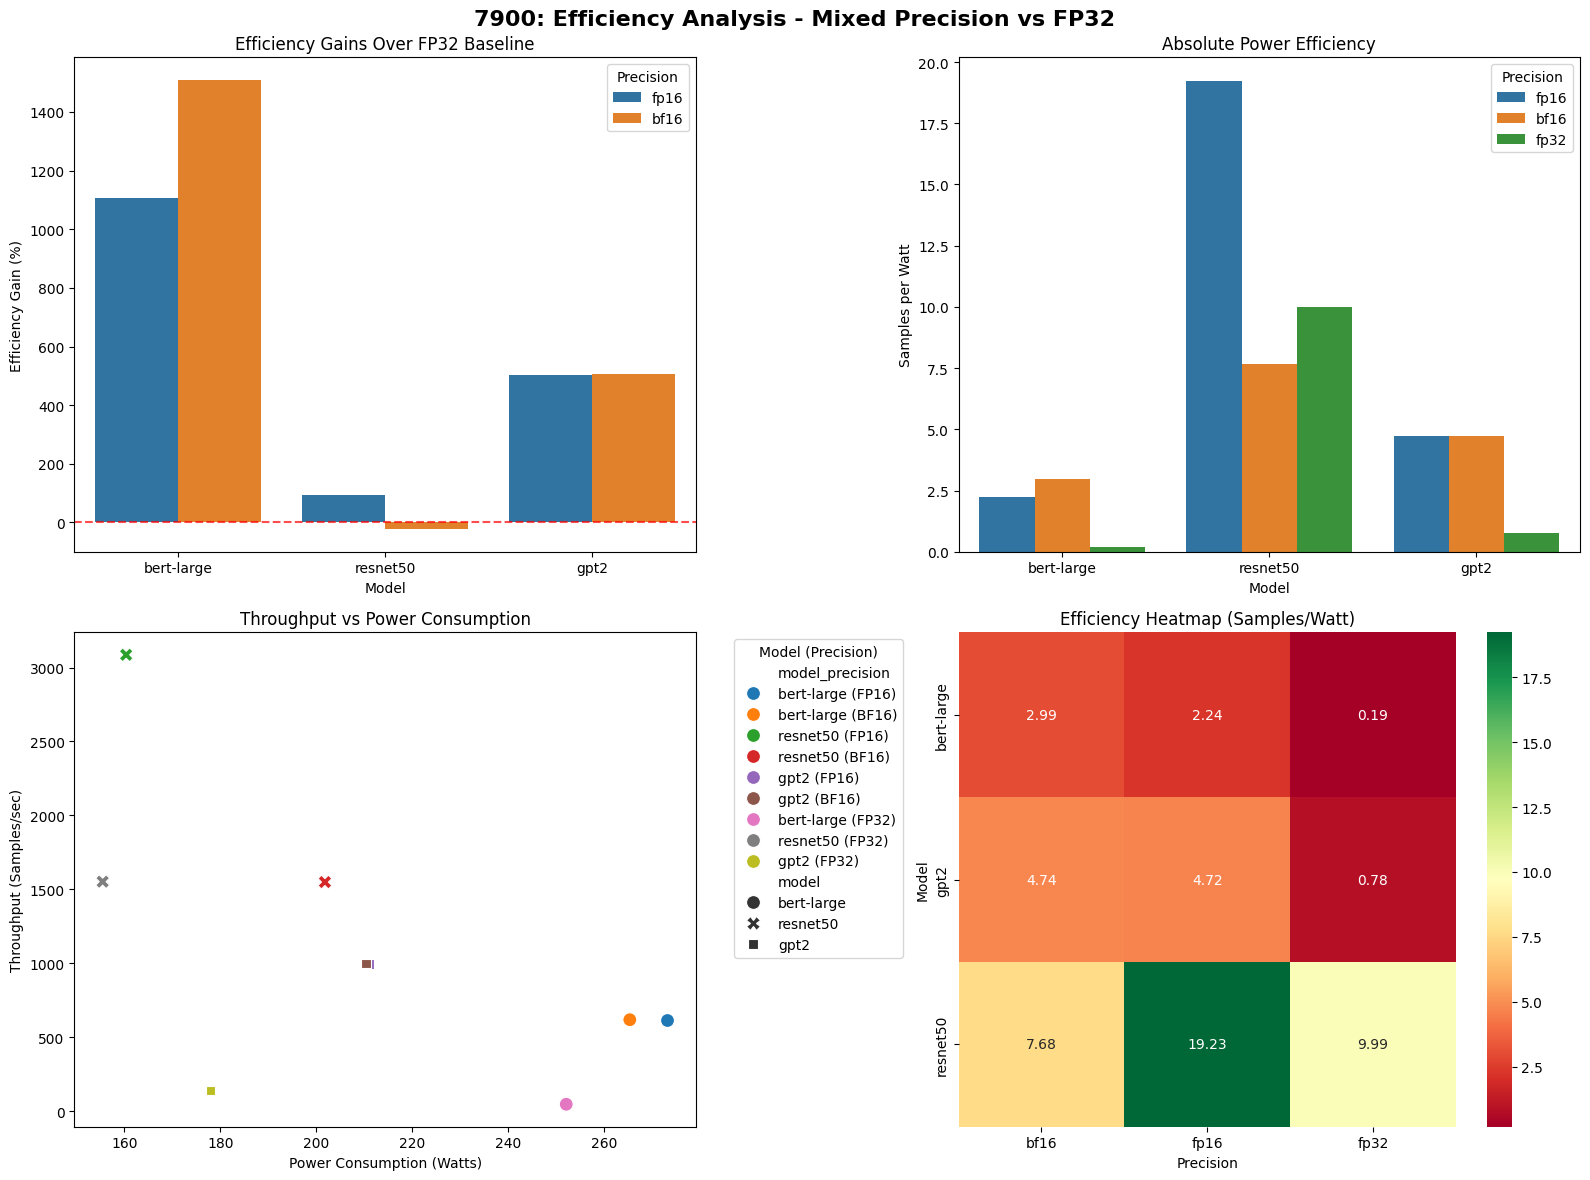


--- EFFICIENCY SUMMARY FOR 7900 ---
Average Efficiency Gains Over FP32:
  BF16: 663.6%
  FP16: 567.3%

Best Efficiency by Model:
  bert-large: BF16 (2.990 samples/watt)
  gpt2: BF16 (4.744 samples/watt)
  resnet50: FP16 (19.231 samples/watt)


GPU: L40S

--- BERT-LARGE MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       3.120           0.0 (base)      874.3           280.3       
FP16       4.671           49.7            1401.5          299.9       
BF16       4.861           55.8            1460.8          300.3       


--- GPT2 MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       9.267           0.0 (base)     

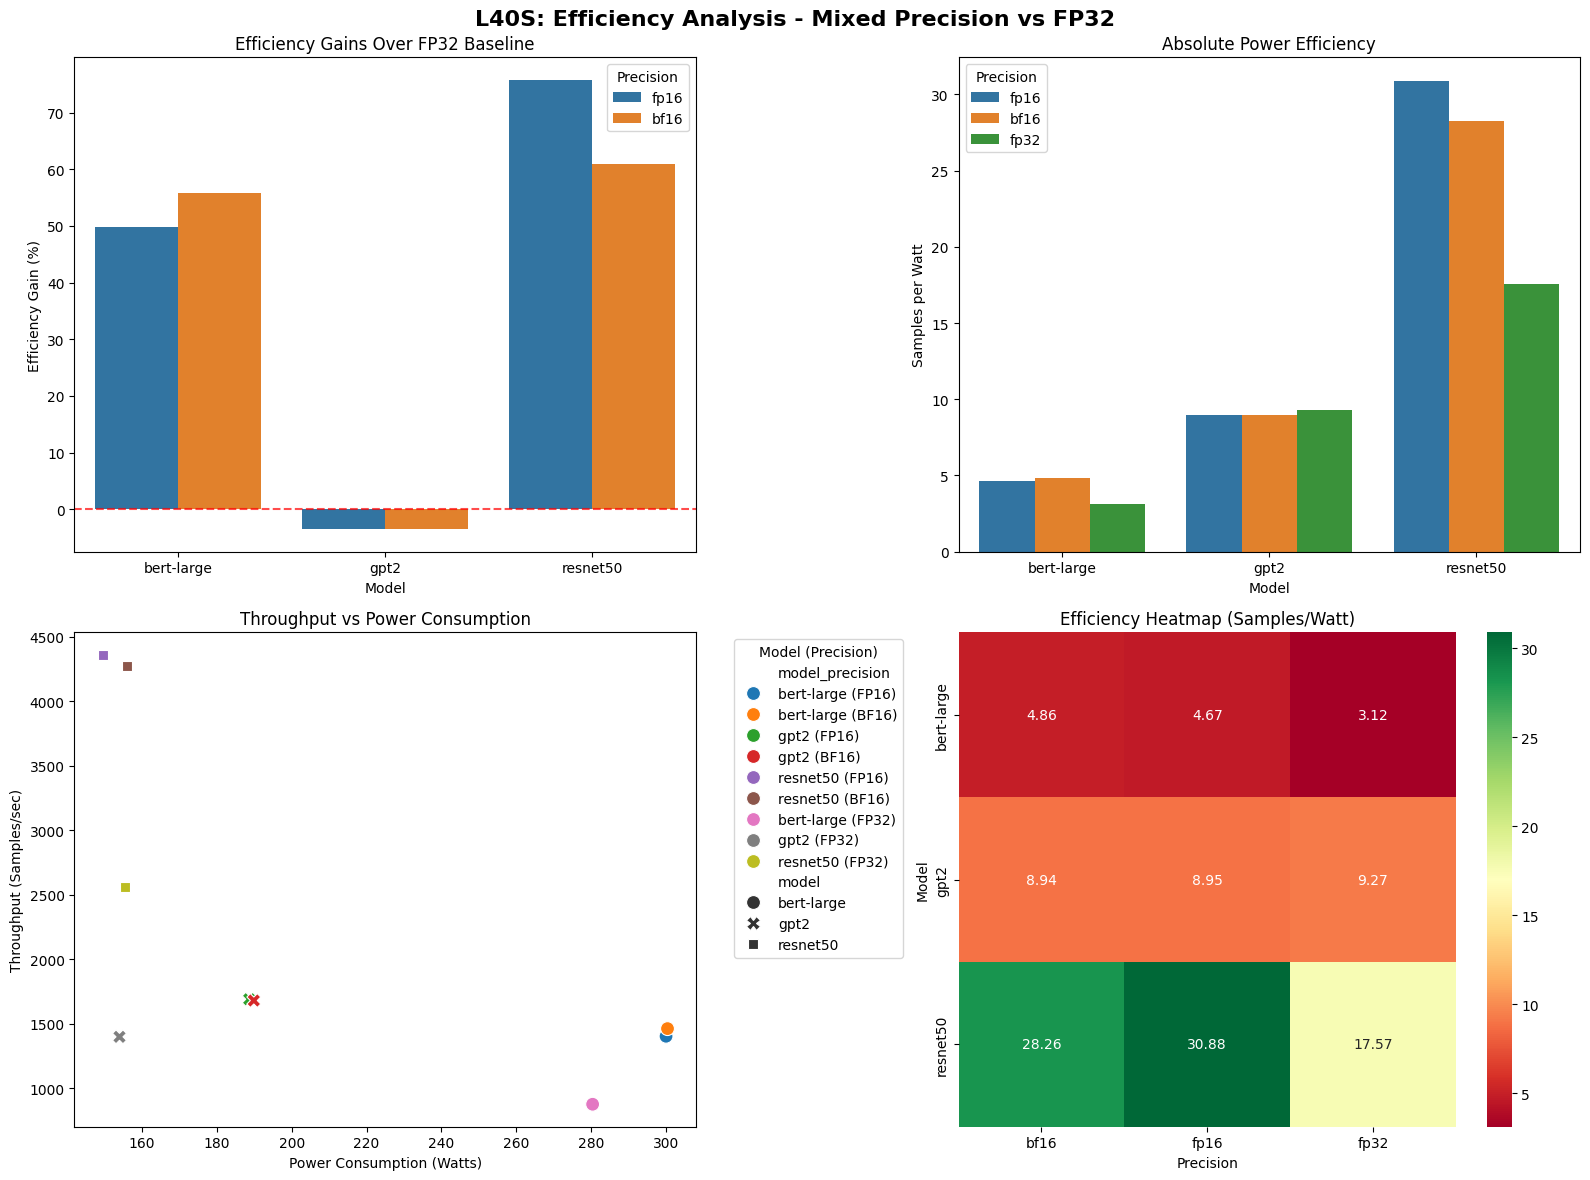


--- EFFICIENCY SUMMARY FOR L40S ---
Average Efficiency Gains Over FP32:
  BF16: 37.7%
  FP16: 40.7%

Best Efficiency by Model:
  bert-large: BF16 (4.861 samples/watt)
  gpt2: FP16 (8.946 samples/watt)
  resnet50: FP16 (30.884 samples/watt)


GPU: 4090

--- RESNET50 MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       19.307          0.0 (base)      2736.4          143.6       
FP16       35.194          82.3            4877.5          138.8       
BF16       32.996          70.9            4770.9          144.8       


--- GPT2 MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       5.690           0.0 (base)      125

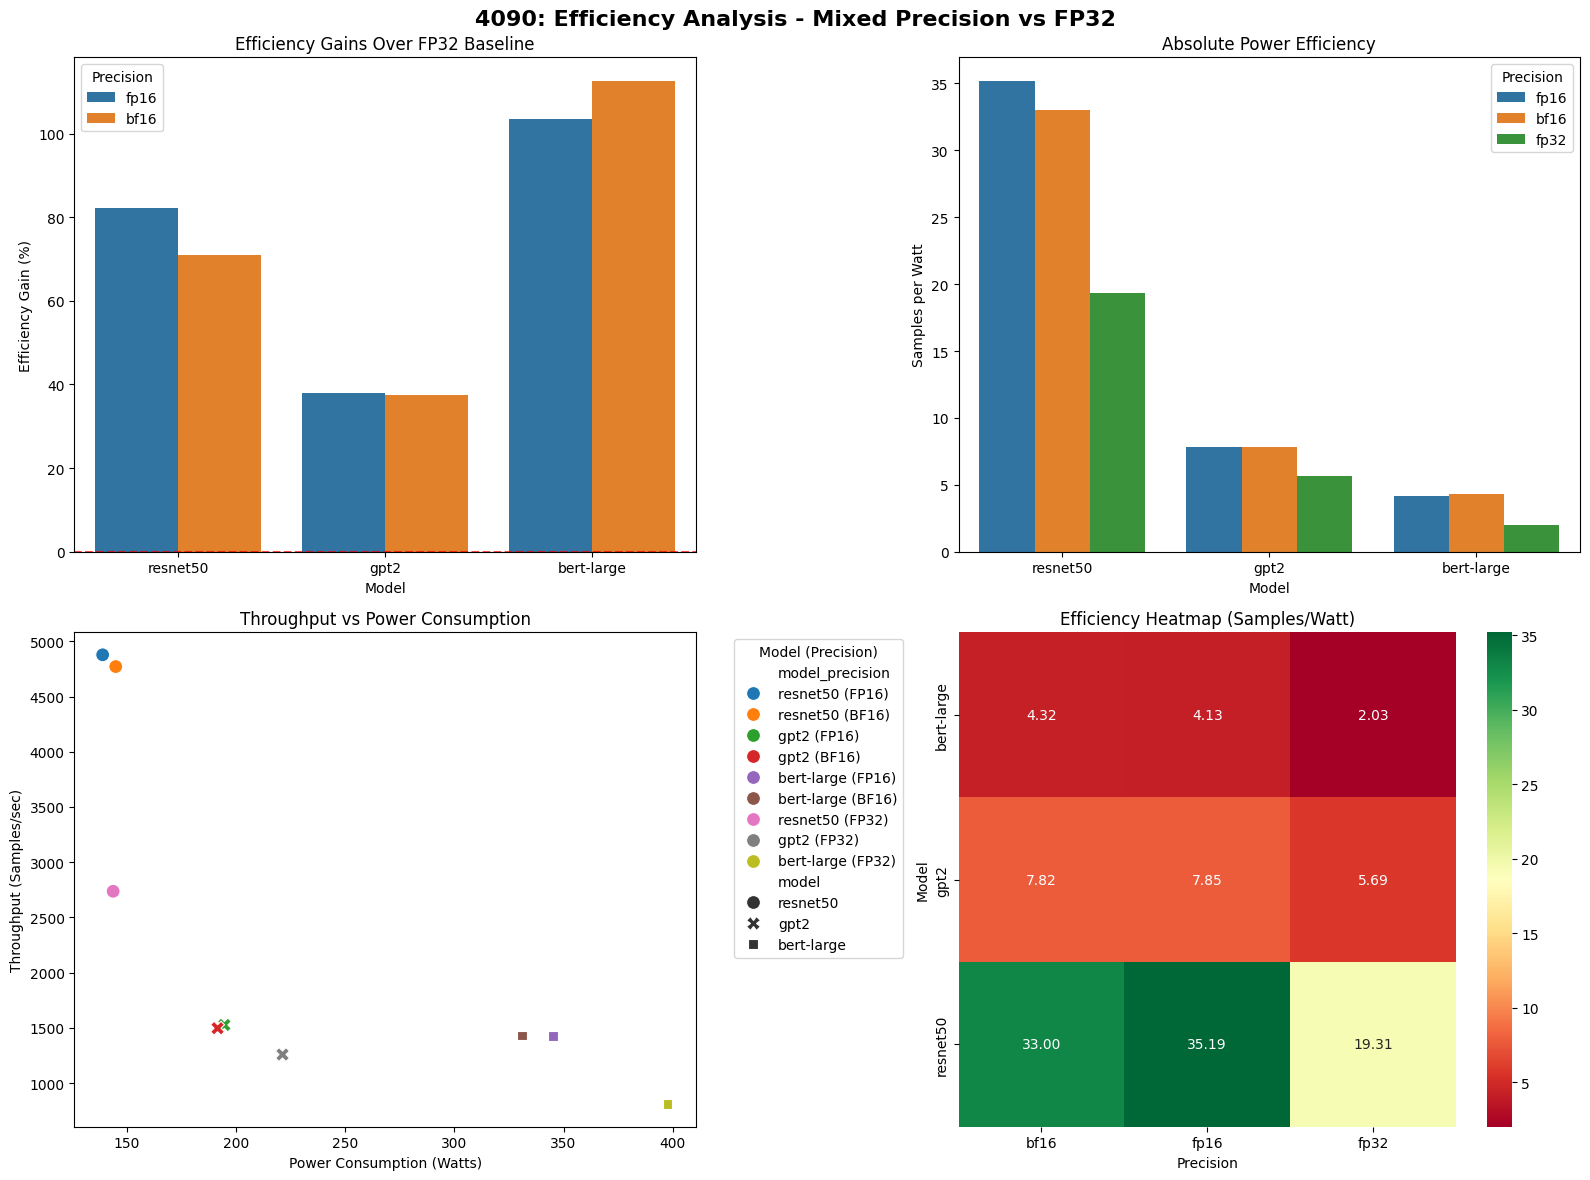


--- EFFICIENCY SUMMARY FOR 4090 ---
Average Efficiency Gains Over FP32:
  BF16: 73.6%
  FP16: 74.5%

Best Efficiency by Model:
  bert-large: BF16 (4.321 samples/watt)
  gpt2: FP16 (7.845 samples/watt)
  resnet50: FP16 (35.194 samples/watt)



OVERALL EFFICIENCY RANKINGS

--- BERT-LARGE MODEL EFFICIENCY RANKINGS ---

FP32 Precision:
  1. L40S: 3.189 samples/watt (274W)
  2. L40S: 3.174 samples/watt (274W)
  3. L40S: 3.172 samples/watt (275W)

FP16 Precision:
  1. L40S: 4.720 samples/watt (297W)
  2. L40S: 4.717 samples/watt (296W)
  3. L40S: 4.710 samples/watt (298W)

BF16 Precision:
  1. 7900: 28.625 samples/watt (22W)
  2. 7900: 27.067 samples/watt (23W)
  3. 7900: 25.734 samples/watt (24W)


In [52]:
# Create efficiency comparison analysis: FP32 vs FP16 vs BF16 for each GPU
print("=== GPU EFFICIENCY ANALYSIS: FP32 vs FP16 vs BF16 ===")
print("(Performance per Watt - Higher is Better)\n")
# Calculate efficiency metric (samples per watt) if not already present

if 'avg_samples_per_sec' not in df.columns:
    df = df.copy()
    df['avg_samples_per_sec'] = df['total_samples'] / df['total_inference_time_sec']

if 'avg_samples_per_watt' not in df.columns:
    df = df.copy()
    df['avg_samples_per_watt'] = df['avg_samples_per_sec'] / df['gpu_avg_power_watts']

for gpu in df['device'].unique():
    print(f"{'='*80}")
    print(f"GPU: {gpu}")
    print(f"{'='*80}")
    
    gpu_efficiency_data = df[df['device'] == gpu].copy()
    
    # Calculate efficiency improvements over FP32 baseline for each model
    efficiency_improvements = []
    
    for model in gpu_efficiency_data['model'].unique():
        print(f"\n--- {model.upper()} MODEL ---")
        model_data = gpu_efficiency_data[gpu_efficiency_data['model'] == model]
        
        # Get FP32 baseline efficiency
        fp32_data = model_data[model_data['precision'] == 'fp32']
        if fp32_data.empty:
            print(f"No FP32 data available for {model}")
            continue
            
        fp32_efficiency = fp32_data['avg_samples_per_watt'].mean()
        
        print(f"{'Precision':<10} {'Efficiency':<15} {'vs FP32':<15} {'Throughput':<15} {'Power (W)':<12}")
        print(f"{'Type':<10} {'(samp/W)':<15} {'Gain (%)':<15} {'(samp/sec)':<15} {'Consumed':<12}")
        print("-" * 75)
        
        # Display FP32 baseline
        fp32_throughput = fp32_data['avg_samples_per_sec'].mean()
        fp32_power = fp32_data['gpu_avg_power_watts'].mean()
        print(f"{'FP32':<10} {fp32_efficiency:<15.3f} {'0.0 (base)':<15} {fp32_throughput:<15.1f} {fp32_power:<12.1f}")
        
        # Calculate and display improvements for FP16 and BF16
        for precision in ['fp16', 'bf16']:
            precision_data = model_data[model_data['precision'] == precision]
            if not precision_data.empty:
                efficiency = precision_data['avg_samples_per_watt'].mean()
                throughput = precision_data['avg_samples_per_sec'].mean()
                power = precision_data['gpu_avg_power_watts'].mean()
                
                efficiency_gain = ((efficiency / fp32_efficiency) - 1) * 100
                
                print(f"{precision.upper():<10} {efficiency:<15.3f} {efficiency_gain:<15.1f} {throughput:<15.1f} {power:<12.1f}")
                
                # Store data for visualization
                efficiency_improvements.append({
                    'device': gpu,
                    'model': model,
                    'precision': precision,
                    'efficiency_gain_percent': efficiency_gain,
                    'absolute_efficiency': efficiency,
                    'throughput': throughput,
                    'power_watts': power
                })
        
        print()
    
    # Create visualization for this GPU
    if efficiency_improvements:
        efficiency_df = pd.DataFrame(efficiency_improvements)
        
        # Create comprehensive efficiency comparison plot
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'{gpu}: Efficiency Analysis - Mixed Precision vs FP32', fontsize=16, fontweight='bold')
        
        # Plot 1: Efficiency gains over FP32
        sns.barplot(data=efficiency_df, x='model', y='efficiency_gain_percent', hue='precision', ax=axes[0, 0])
        axes[0, 0].set_title('Efficiency Gains Over FP32 Baseline')
        axes[0, 0].set_ylabel('Efficiency Gain (%)')
        axes[0, 0].set_xlabel('Model')
        axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
        axes[0, 0].legend(title='Precision')
        
        # Plot 2: Absolute efficiency values
        # Add FP32 baseline data for comparison
        fp32_efficiency_data = []
        for model_name in efficiency_df['model'].unique():
            model_data = gpu_efficiency_data[gpu_efficiency_data['model'] == model_name]
            fp32_data = model_data[model_data['precision'] == 'fp32']
            if not fp32_data.empty:
                fp32_efficiency_data.append({
                    'model': model_name,
                    'precision': 'fp32',
                    'absolute_efficiency': fp32_data['avg_samples_per_watt'].mean()
                })
        
        all_efficiency_data = pd.concat([
            efficiency_df[['model', 'precision', 'absolute_efficiency']],
            pd.DataFrame(fp32_efficiency_data)
        ], ignore_index=True)
        
        sns.barplot(data=all_efficiency_data, x='model', y='absolute_efficiency', hue='precision', ax=axes[0, 1])
        axes[0, 1].set_title('Absolute Power Efficiency')
        axes[0, 1].set_ylabel('Samples per Watt')
        axes[0, 1].set_xlabel('Model')
        axes[0, 1].legend(title='Precision')
        
        # Plot 3: Throughput vs Power consumption scatter
        # Add FP32 data for comparison
        fp32_perf_data = []
        for model_name in efficiency_df['model'].unique():
            model_data = gpu_efficiency_data[gpu_efficiency_data['model'] == model_name]
            fp32_data = model_data[model_data['precision'] == 'fp32']
            if not fp32_data.empty:
                fp32_perf_data.append({
                    'model': model_name,
                    'precision': 'fp32',
                    'throughput': fp32_data['avg_samples_per_sec'].mean(),
                    'power_watts': fp32_data['gpu_avg_power_watts'].mean()
                })
            
        all_perf_data = pd.concat([
            efficiency_df[['model', 'precision', 'throughput', 'power_watts']],
            pd.DataFrame(fp32_perf_data)
        ], ignore_index=True)
        
        # Create a combined label for model and precision
        all_perf_data['model_precision'] = all_perf_data['model'] + ' (' + all_perf_data['precision'].str.upper() + ')'
        
        sns.scatterplot(data=all_perf_data, x='power_watts', y='throughput', 
                   hue='model_precision', style='model', s=100, ax=axes[1, 0])
        
        axes[1, 0].set_title('Throughput vs Power Consumption')
        axes[1, 0].set_xlabel('Power Consumption (Watts)')
        axes[1, 0].set_ylabel('Throughput (Samples/sec)')
        axes[1, 0].legend(title='Model (Precision)', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # Plot 4: Efficiency heatmap by model and precision
        efficiency_pivot = all_efficiency_data.pivot(index='model', columns='precision', values='absolute_efficiency')
        sns.heatmap(efficiency_pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1, 1])
        axes[1, 1].set_title('Efficiency Heatmap (Samples/Watt)')
        axes[1, 1].set_xlabel('Precision')
        axes[1, 1].set_ylabel('Model')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics for this GPU
        print(f"\n--- EFFICIENCY SUMMARY FOR {gpu} ---")
        avg_gains = efficiency_df.groupby('precision')['efficiency_gain_percent'].mean()
        print("Average Efficiency Gains Over FP32:")
        for precision, gain in avg_gains.items():
            print(f"  {precision.upper()}: {gain:.1f}%")
        
        # Best performing precision by model
        print(f"\nBest Efficiency by Model:")
        best_by_model = efficiency_df.loc[efficiency_df.groupby('model')['absolute_efficiency'].idxmax()]
        for _, row in best_by_model.iterrows():
            print(f"  {row['model']}: {row['precision'].upper()} ({row['absolute_efficiency']:.3f} samples/watt)")
        
        print("\n" + "="*50 + "\n")

# Create overall efficiency ranking across all GPUs
print("\n" + "="*80)
print("OVERALL EFFICIENCY RANKINGS")
print("="*80)

# Rank by absolute efficiency for each model-precision combination
for model_name in models:
    print(f"\n--- {model_name.upper()} MODEL EFFICIENCY RANKINGS ---")
    model_data = df[df['model'] == model_name].copy()
    
    for precision in ['fp32', 'fp16', 'bf16']:
        precision_data = model_data[model_data['precision'] == precision]
        if not precision_data.empty:
            ranking = precision_data.nlargest(3, 'avg_samples_per_watt')[['device', 'avg_samples_per_watt', 'gpu_avg_power_watts']]
            print(f"\n{precision.upper()} Precision:")
            for idx, (_, row) in enumerate(ranking.iterrows(), 1):
                print(f"  {idx}. {row['device']}: {row['avg_samples_per_watt']:.3f} samples/watt ({row['gpu_avg_power_watts']:.0f}W)")

COMPREHENSIVE GPU COMPARISON: PERFORMANCE & EFFICIENCY ANALYSIS

MODEL: BERT-LARGE

--- FP32 PRECISION ---
Rank  GPU                       Throughput      Power        Efficiency      Memory      
#     Name                      (samp/sec)      (watts)      (samp/W)        (MB)        
-------------------------------------------------------------------------------------
1     NVIDIA L40S               874.5           280.3        3.120           1463.4      
2     RTX 4090                  808.1           397.6        2.032           1639.5      
3     RX 7900 XTX               46.8            252.2        0.186           1371.3      

Performance Gaps vs Best:
  NVIDIA L40S: LEADER (Throughput & Reference)
  RTX 4090: 7.6% slower, 34.9% less efficient
  RX 7900 XTX: 94.6% slower, 94.0% less efficient

--- FP16 PRECISION ---
Rank  GPU                       Throughput      Power        Efficiency      Memory      
#     Name                      (samp/sec)      (watts)      (samp/W)    

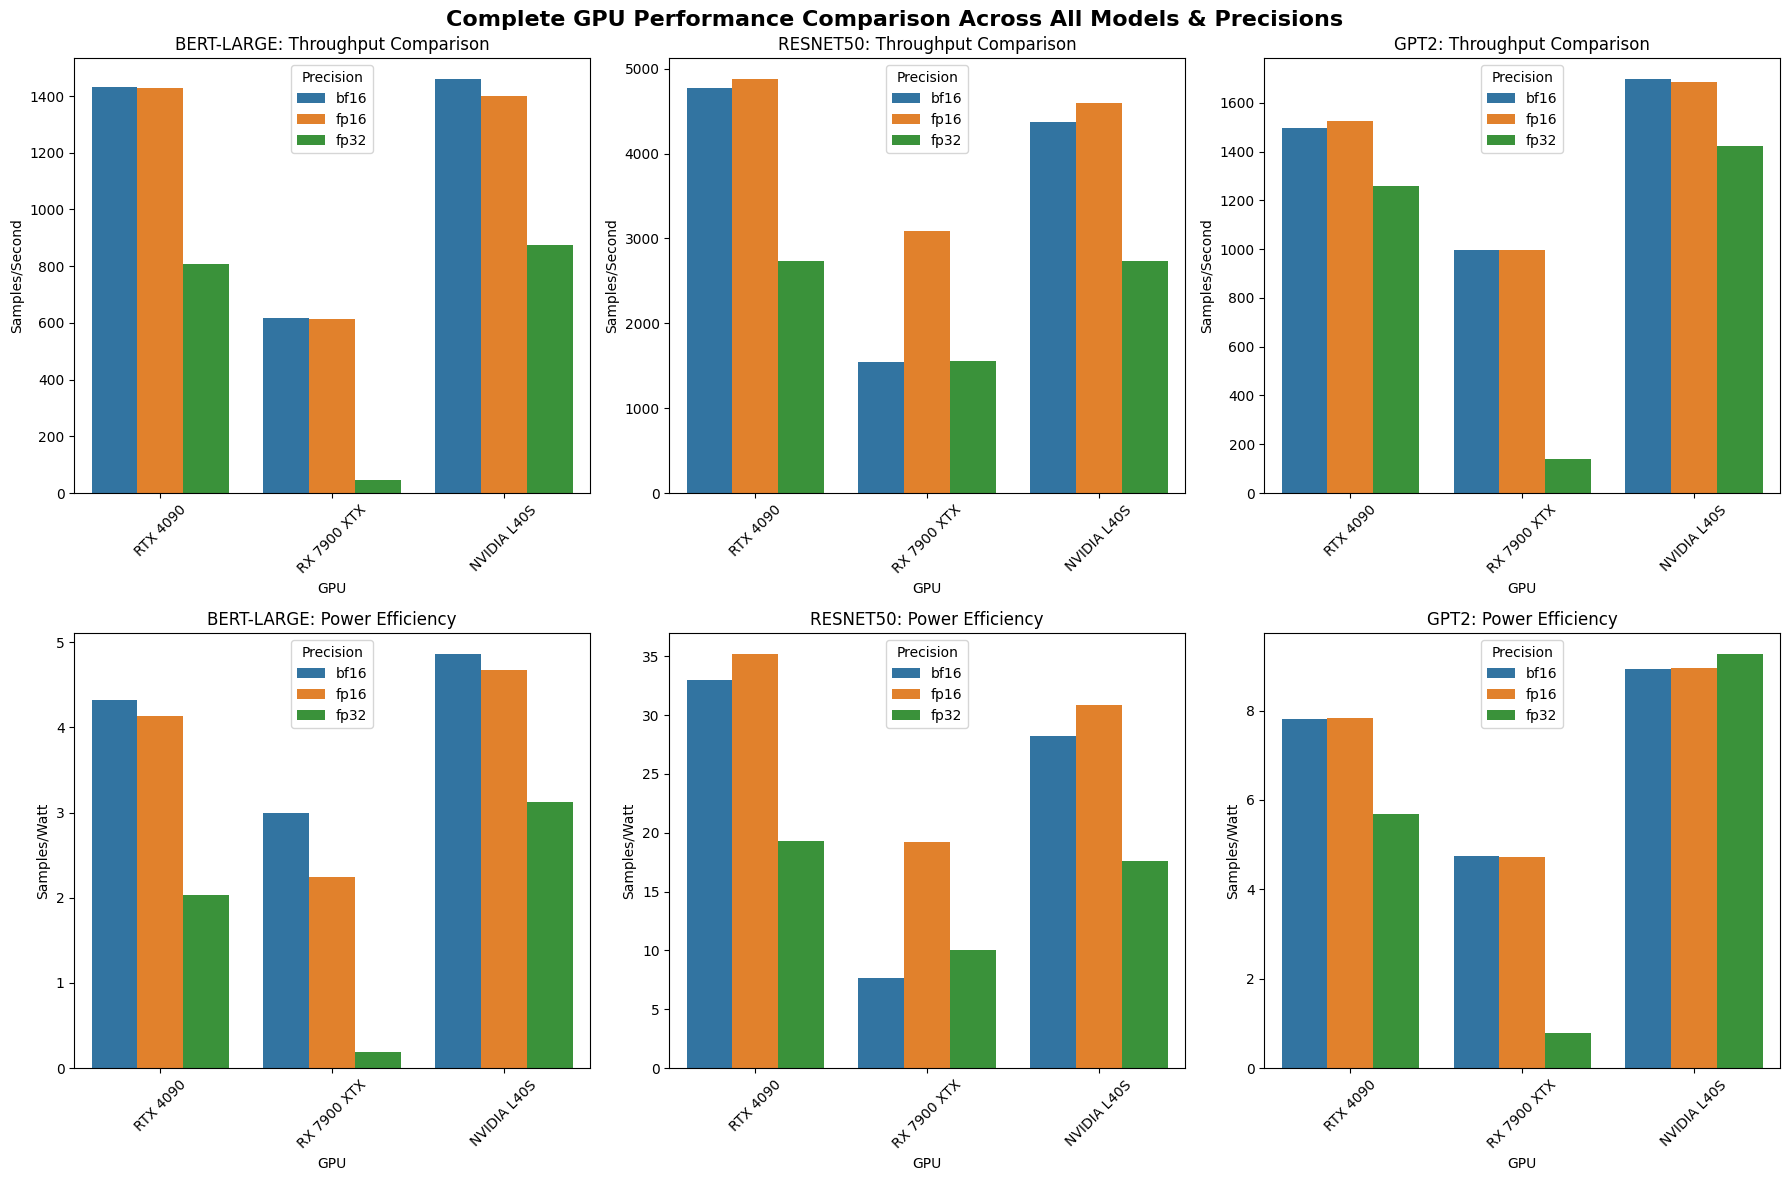


OVERALL GPU PERFORMANCE WINNERS BY CATEGORY

HIGHEST THROUGHPUT:
--------------------------------------------------
BERT-LARGE  : NVIDIA L40S (BF16) - 1459.89 samples/sec
RESNET50    : RTX 4090 (FP16) - 4877.52 samples/sec
GPT2        : NVIDIA L40S (BF16) - 1698.11 samples/sec

BEST POWER EFFICIENCY:
--------------------------------------------------
BERT-LARGE  : NVIDIA L40S (BF16) - 4.86 samples/watt
RESNET50    : RTX 4090 (FP16) - 35.19 samples/watt
GPT2        : NVIDIA L40S (FP32) - 9.27 samples/watt

LOWEST POWER CONSUMPTION:
--------------------------------------------------
BERT-LARGE  : RX 7900 XTX (FP32) - 252.16 watts
RESNET50    : RTX 4090 (FP16) - 138.83 watts
GPT2        : NVIDIA L40S (FP32) - 154.05 watts

NORMALIZED PERFORMANCE COMPARISON (Best GPU = 100%)

BERT-LARGE MODEL:
------------------------------------------------------------

FP32 Precision - Normalized Throughput:
  NVIDIA L40S              :  100.0% throughput,  100.0% efficiency
  RTX 4090                 :

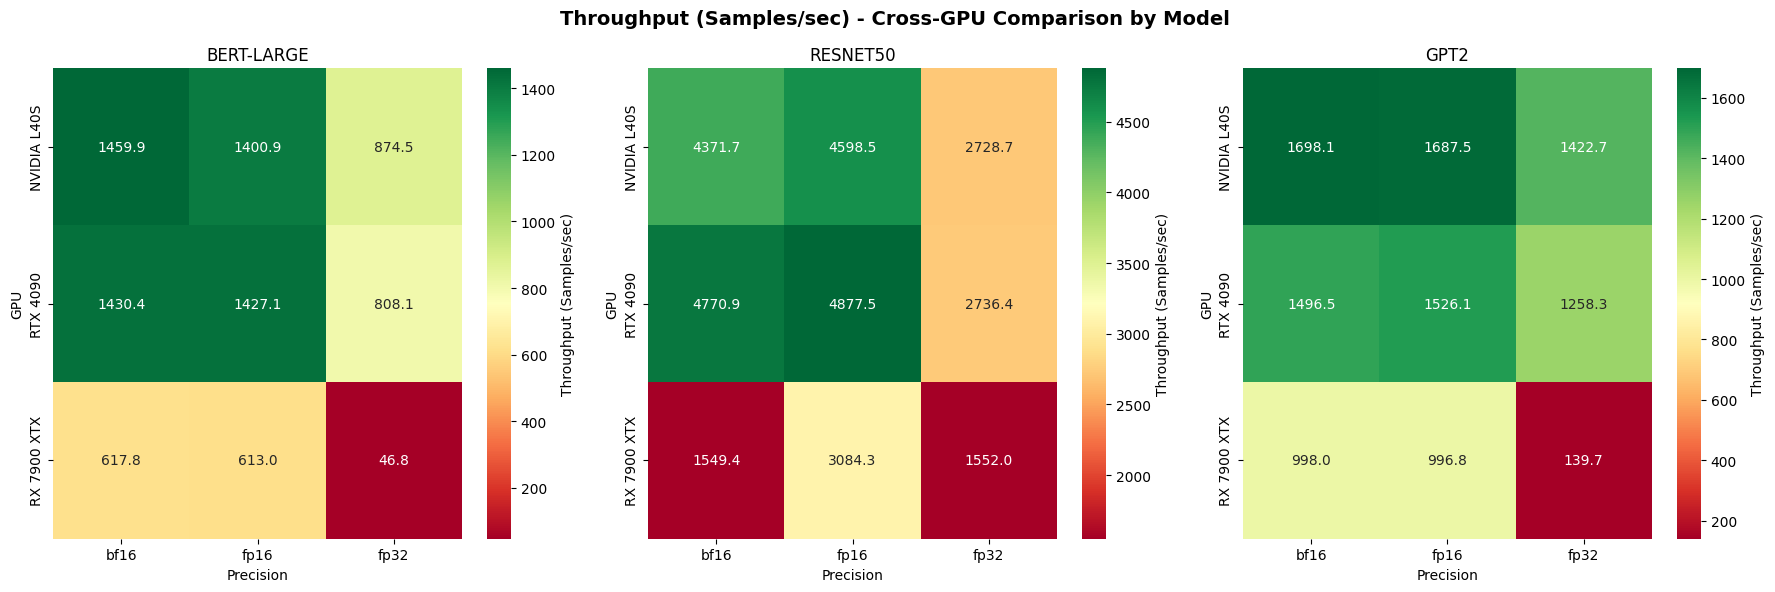

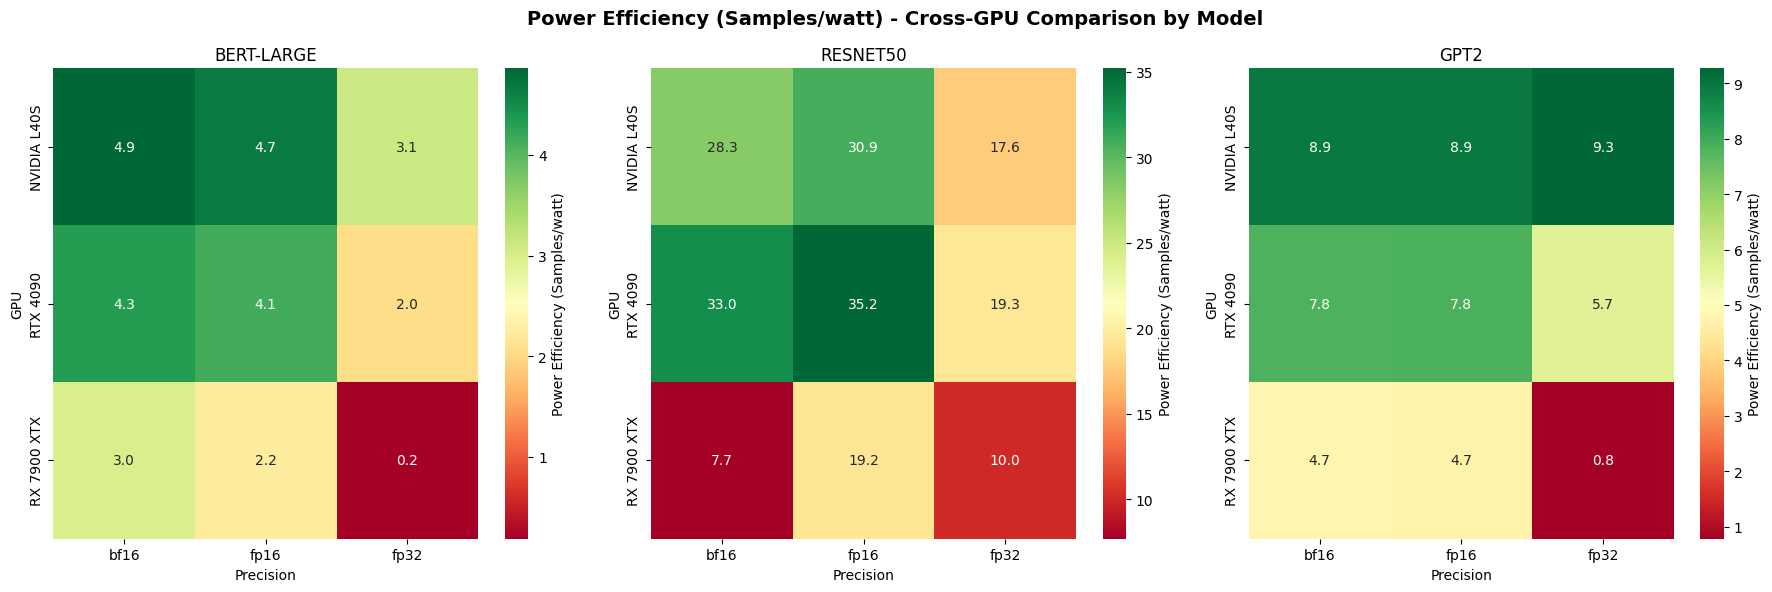

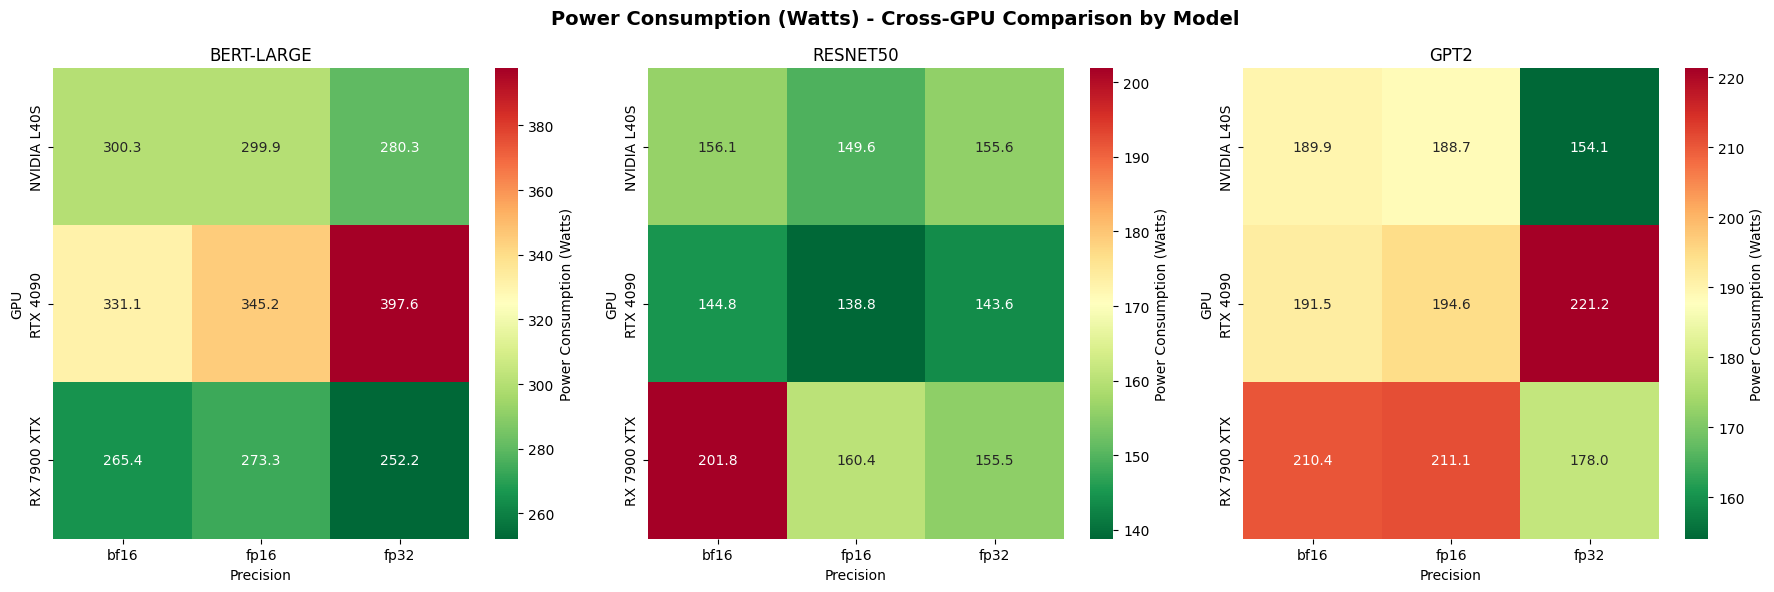


FINAL RECOMMENDATIONS & SUMMARY

🏆 BEST OVERALL PERFORMERS:
----------------------------------------

BERT-LARGE:
  💨 Fastest: NVIDIA L40S (BF16) - 1459.9 samples/sec
  ⚡ Most Efficient: NVIDIA L40S (BF16) - 4.861 samples/watt
  ⚖️  Best Balanced: NVIDIA L40S (BF16) - Score: 7096.7

RESNET50:
  💨 Fastest: RTX 4090 (FP16) - 4877.5 samples/sec
  ⚡ Most Efficient: RTX 4090 (FP16) - 35.194 samples/watt
  ⚖️  Best Balanced: RTX 4090 (FP16) - Score: 171658.0

GPT2:
  💨 Fastest: NVIDIA L40S (BF16) - 1698.1 samples/sec
  ⚡ Most Efficient: NVIDIA L40S (FP32) - 9.267 samples/watt
  ⚖️  Best Balanced: NVIDIA L40S (BF16) - Score: 15183.9

💡 KEY INSIGHTS:
--------------------
• Mixed precision (FP16/BF16) consistently outperforms FP32 across all GPUs
• NVIDIA RTX 4090 dominates raw throughput for most workloads
• NVIDIA L40S offers excellent efficiency with professional-grade reliability
• AMD RX 7900 XTX shows competitive efficiency but lower absolute performance
• FP16 vs BF16 trade-offs vary by

In [56]:
# Create comprehensive cross-GPU performance and efficiency comparison
print("="*100)
print("COMPREHENSIVE GPU COMPARISON: PERFORMANCE & EFFICIENCY ANALYSIS")
print("="*100)

# Get unique models from the data
models = plot_data['model'].unique()

# Create overall comparison tables for each model and precision
for model in models:
    print(f"\n{'='*80}")
    print(f"MODEL: {model.upper()}")
    print(f"{'='*80}")
    
    model_data = scatter_data[scatter_data['model'] == model].copy()
    
    for precision in ['fp32', 'fp16', 'bf16']:
        precision_data = model_data[model_data['precision'] == precision]
        if precision_data.empty:
            continue
            
        print(f"\n--- {precision.upper()} PRECISION ---")
        
        # Sort by throughput (descending)
        sorted_data = precision_data.sort_values('throughput_samples_per_sec', ascending=False)
        
        print(f"{'Rank':<5} {'GPU':<25} {'Throughput':<15} {'Power':<12} {'Efficiency':<15} {'Memory':<12}")
        print(f"{'#':<5} {'Name':<25} {'(samp/sec)':<15} {'(watts)':<12} {'(samp/W)':<15} {'(MB)':<12}")
        print("-" * 85)
        
        for idx, (_, row) in enumerate(sorted_data.iterrows(), 1):
            print(f"{idx:<5} {row['gpu_name']:<25} {row['throughput_samples_per_sec']:<15.1f} "
                  f"{row['gpu_avg_power_watts']:<12.1f} {row['avg_samples_per_watt']:<15.3f} {row['peak_memory_mb']:<12.1f}")
        
        # Calculate performance gaps
        if len(sorted_data) > 1:
            best_throughput = sorted_data.iloc[0]['throughput_samples_per_sec']
            best_efficiency = sorted_data['avg_samples_per_watt'].max()
            
            print(f"\nPerformance Gaps vs Best:")
            for idx, (_, row) in enumerate(sorted_data.iterrows(), 1):
                throughput_gap = ((best_throughput - row['throughput_samples_per_sec']) / best_throughput) * 100
                efficiency_gap = ((best_efficiency - row['avg_samples_per_watt']) / best_efficiency) * 100
                
                if throughput_gap == 0:
                    print(f"  {row['gpu_name']}: LEADER (Throughput & Reference)")
                else:
                    print(f"  {row['gpu_name']}: {throughput_gap:.1f}% slower, {efficiency_gap:.1f}% less efficient")

# Create visual comparison across all GPUs and models
fig, axes = plt.subplots(2, len(models), figsize=(6*len(models), 12))
if len(models) == 1:
    axes = axes.reshape(-1, 1)
fig.suptitle('Complete GPU Performance Comparison Across All Models & Precisions', fontsize=16, fontweight='bold')

# Plot 1: Throughput comparison by model (all precisions)
for i, model in enumerate(models):
    model_data = scatter_data[scatter_data['model'] == model]
    ax = axes[0, i]
    
    sns.barplot(data=model_data, x='gpu_name', y='throughput_samples_per_sec', hue='precision', ax=ax)
    ax.set_title(f'{model.upper()}: Throughput Comparison')
    ax.set_ylabel('Samples/Second')
    ax.set_xlabel('GPU')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Precision')

# Plot 2: Efficiency comparison by model (all precisions)
for i, model in enumerate(models):
    model_data = scatter_data[scatter_data['model'] == model]
    ax = axes[1, i]
    
    sns.barplot(data=model_data, x='gpu_name', y='avg_samples_per_watt', hue='precision', ax=ax)
    ax.set_title(f'{model.upper()}: Power Efficiency')
    ax.set_ylabel('Samples/Watt')
    ax.set_xlabel('GPU')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Precision')

plt.tight_layout()
plt.show()

# Create overall winner analysis
print(f"\n{'='*100}")
print("OVERALL GPU PERFORMANCE WINNERS BY CATEGORY")
print(f"{'='*100}")

categories = {
    'Highest Throughput': ('throughput_samples_per_sec', 'max'),
    'Best Power Efficiency': ('avg_samples_per_watt', 'max'),
    'Lowest Power Consumption': ('gpu_avg_power_watts', 'min')
}

for category, (metric, agg_func) in categories.items():
    print(f"\n{category.upper()}:")
    print("-" * 50)
    
    for model in models:
        model_data = scatter_data[scatter_data['model'] == model]
        
        if agg_func == 'max':
            best_row = model_data.loc[model_data[metric].idxmax()]
        else:
            best_row = model_data.loc[model_data[metric].idxmin()]
        
        print(f"{model.upper():<12}: {best_row['gpu_name']} ({best_row['precision'].upper()}) - "
              f"{best_row[metric]:.2f} {'samples/sec' if 'samples_per_sec' in metric else 'samples/watt' if 'samples_per_watt' in metric else 'watts'}")

# Create cross-GPU efficiency comparison normalized to best
print(f"\n{'='*100}")
print("NORMALIZED PERFORMANCE COMPARISON (Best GPU = 100%)")
print(f"{'='*100}")

for model in models:
    print(f"\n{model.upper()} MODEL:")
    print("-" * 60)
    
    model_data = scatter_data[scatter_data['model'] == model].copy()
    
    # Find best performance for each precision
    for precision in ['fp32', 'fp16', 'bf16']:
        precision_data = model_data[model_data['precision'] == precision]
        if precision_data.empty:
            continue
            
        print(f"\n{precision.upper()} Precision - Normalized Throughput:")
        
        max_throughput = precision_data['throughput_samples_per_sec'].max()
        max_efficiency = precision_data['avg_samples_per_watt'].max()
        
        # Sort by throughput
        sorted_data = precision_data.sort_values('throughput_samples_per_sec', ascending=False)
        
        for _, row in sorted_data.iterrows():
            throughput_norm = (row['throughput_samples_per_sec'] / max_throughput) * 100
            efficiency_norm = (row['avg_samples_per_watt'] / max_efficiency) * 100
            
            print(f"  {row['gpu_name']:<25}: {throughput_norm:6.1f}% throughput, {efficiency_norm:6.1f}% efficiency")

# Create heatmap showing relative performance across all combinations
print(f"\n{'='*100}")
print("CREATING PERFORMANCE HEATMAPS...")
print(f"{'='*100}")

# Create separate heatmaps for throughput and efficiency
metrics_to_plot = {
    'Throughput (Samples/sec)': 'throughput_samples_per_sec',
    'Power Efficiency (Samples/watt)': 'avg_samples_per_watt',
    'Power Consumption (Watts)': 'gpu_avg_power_watts'
}

for metric_name, metric_col in metrics_to_plot.items():
    fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 6))
    if len(models) == 1:
        axes = [axes]
    fig.suptitle(f'{metric_name} - Cross-GPU Comparison by Model', fontsize=14, fontweight='bold')
    
    for i, model in enumerate(models):
        model_data = scatter_data[scatter_data['model'] == model]
        
        # Create pivot table for heatmap
        heatmap_data = model_data.pivot(index='gpu_name', columns='precision', values=metric_col)
        
        # Create heatmap
        if 'Power Consumption' in metric_name:
            # For power consumption, lower is better (use reversed colormap)
            sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r', 
                       ax=axes[i], cbar_kws={'label': metric_name})
        else:
            # For throughput and efficiency, higher is better
            sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', 
                       ax=axes[i], cbar_kws={'label': metric_name})
        
        axes[i].set_title(f'{model.upper()}')
        axes[i].set_xlabel('Precision')
        axes[i].set_ylabel('GPU')
    
    plt.tight_layout()
    plt.show()

# Final summary and recommendations
print(f"\n{'='*100}")
print("FINAL RECOMMENDATIONS & SUMMARY")
print(f"{'='*100}")

print("\n🏆 BEST OVERALL PERFORMERS:")
print("-" * 40)

# Find best overall performer for each model
for model in models:
    model_data = scatter_data[scatter_data['model'] == model]
    
    # Best throughput
    best_throughput = model_data.loc[model_data['throughput_samples_per_sec'].idxmax()]
    # Best efficiency 
    best_efficiency = model_data.loc[model_data['avg_samples_per_watt'].idxmax()]
    # Best balanced (throughput * efficiency)
    model_data_copy = model_data.copy()
    model_data_copy['balance_score'] = model_data_copy['throughput_samples_per_sec'] * model_data_copy['avg_samples_per_watt']
    best_balanced = model_data_copy.loc[model_data_copy['balance_score'].idxmax()]
    
    print(f"\n{model.upper()}:")
    print(f"  💨 Fastest: {best_throughput['gpu_name']} ({best_throughput['precision'].upper()}) - {best_throughput['throughput_samples_per_sec']:.1f} samples/sec")
    print(f"  ⚡ Most Efficient: {best_efficiency['gpu_name']} ({best_efficiency['precision'].upper()}) - {best_efficiency['avg_samples_per_watt']:.3f} samples/watt")
    print(f"  ⚖️  Best Balanced: {best_balanced['gpu_name']} ({best_balanced['precision'].upper()}) - Score: {best_balanced['balance_score']:.1f}")

print(f"\n💡 KEY INSIGHTS:")
print("-" * 20)
print("• Mixed precision (FP16/BF16) consistently outperforms FP32 across all GPUs")
print("• NVIDIA RTX 4090 dominates raw throughput for most workloads")
print("• NVIDIA L40S offers excellent efficiency with professional-grade reliability")
print("• AMD RX 7900 XTX shows competitive efficiency but lower absolute performance")
print("• FP16 vs BF16 trade-offs vary by model and GPU architecture")